In [1]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/frequency_experiment_9'

errors_df_org = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
entries_df_org = pd.read_csv(os.path.join(dir, 'entries.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)


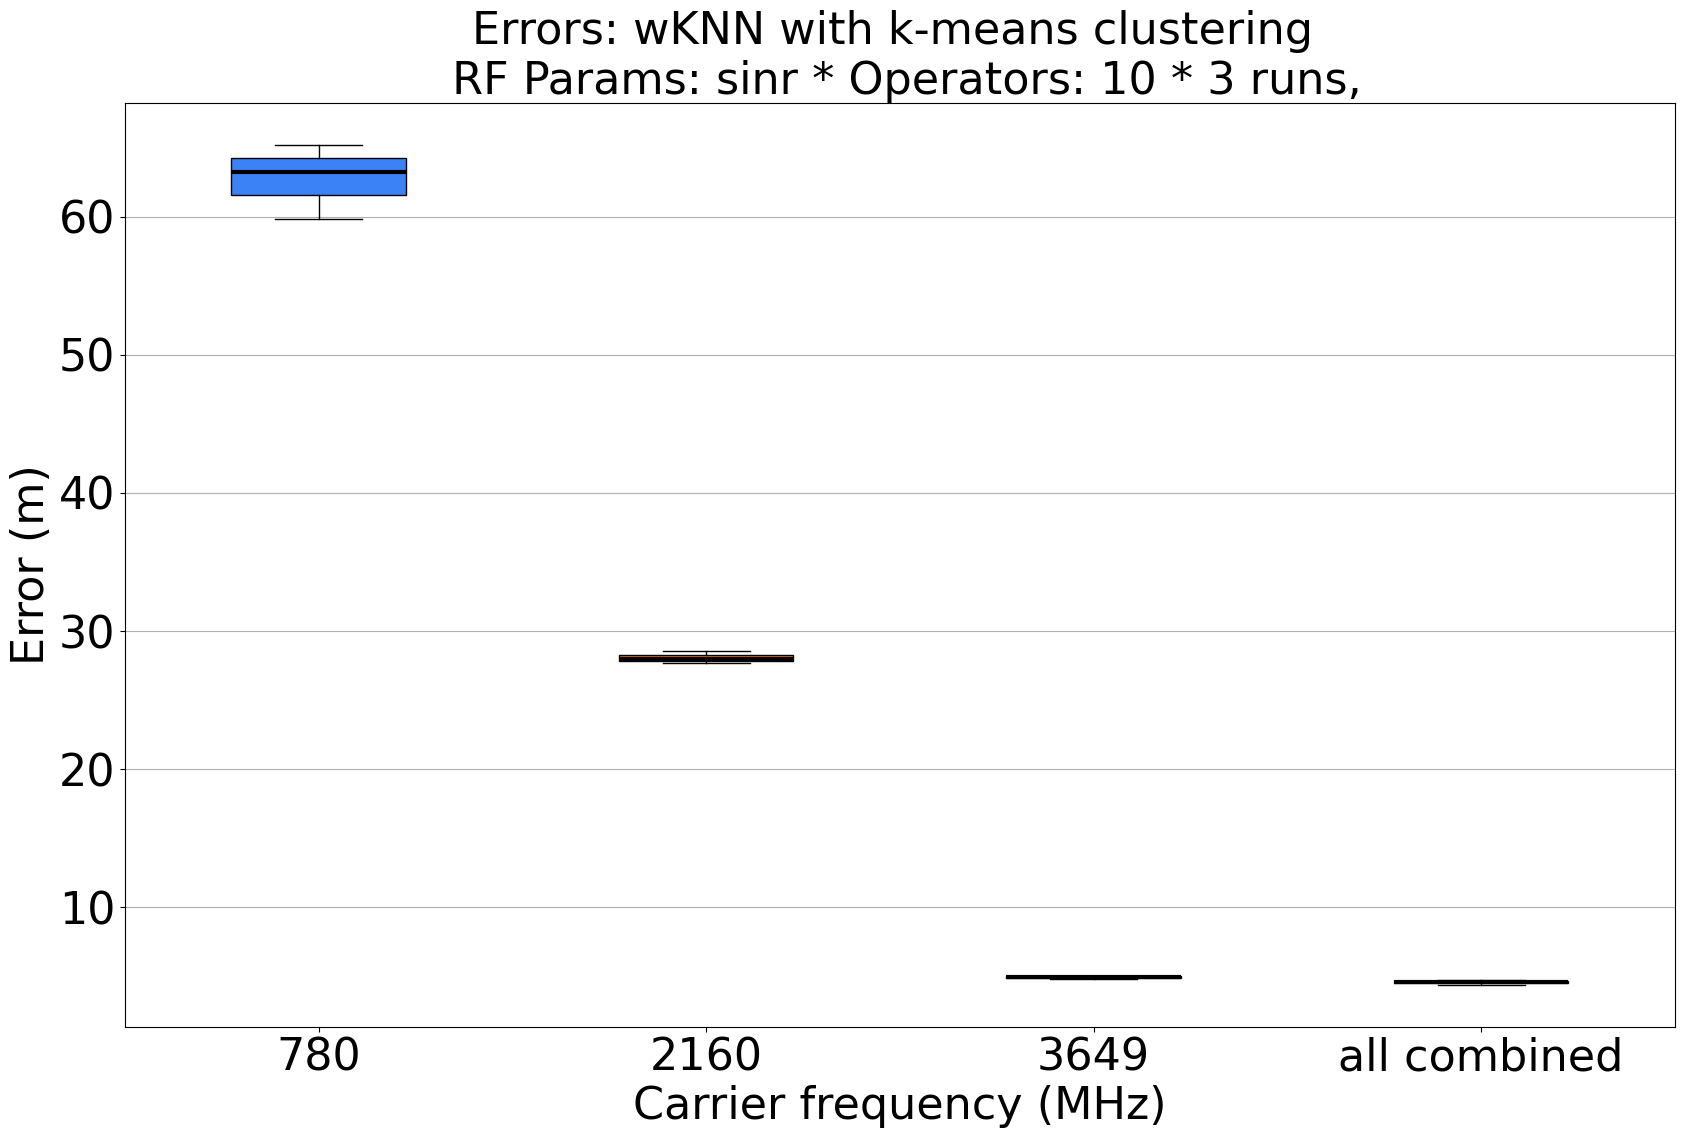

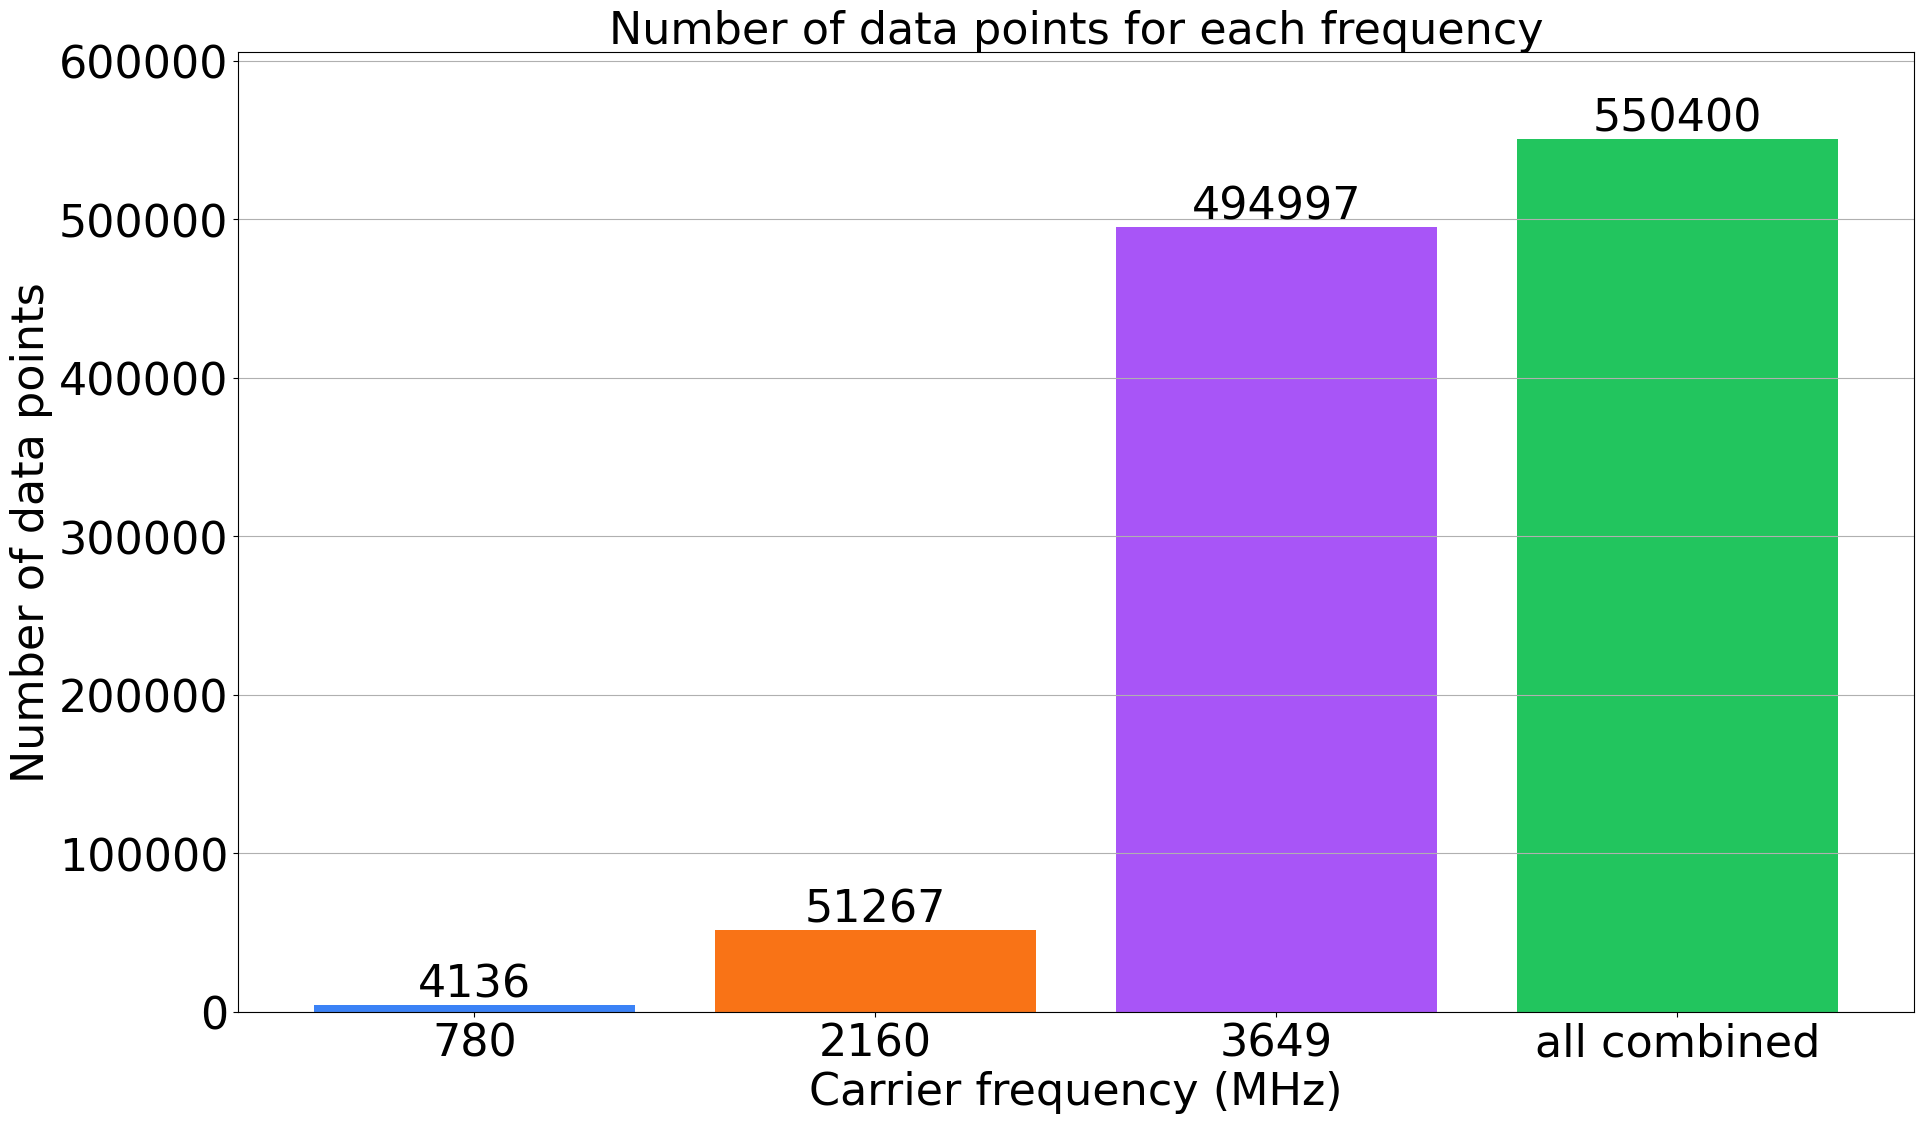

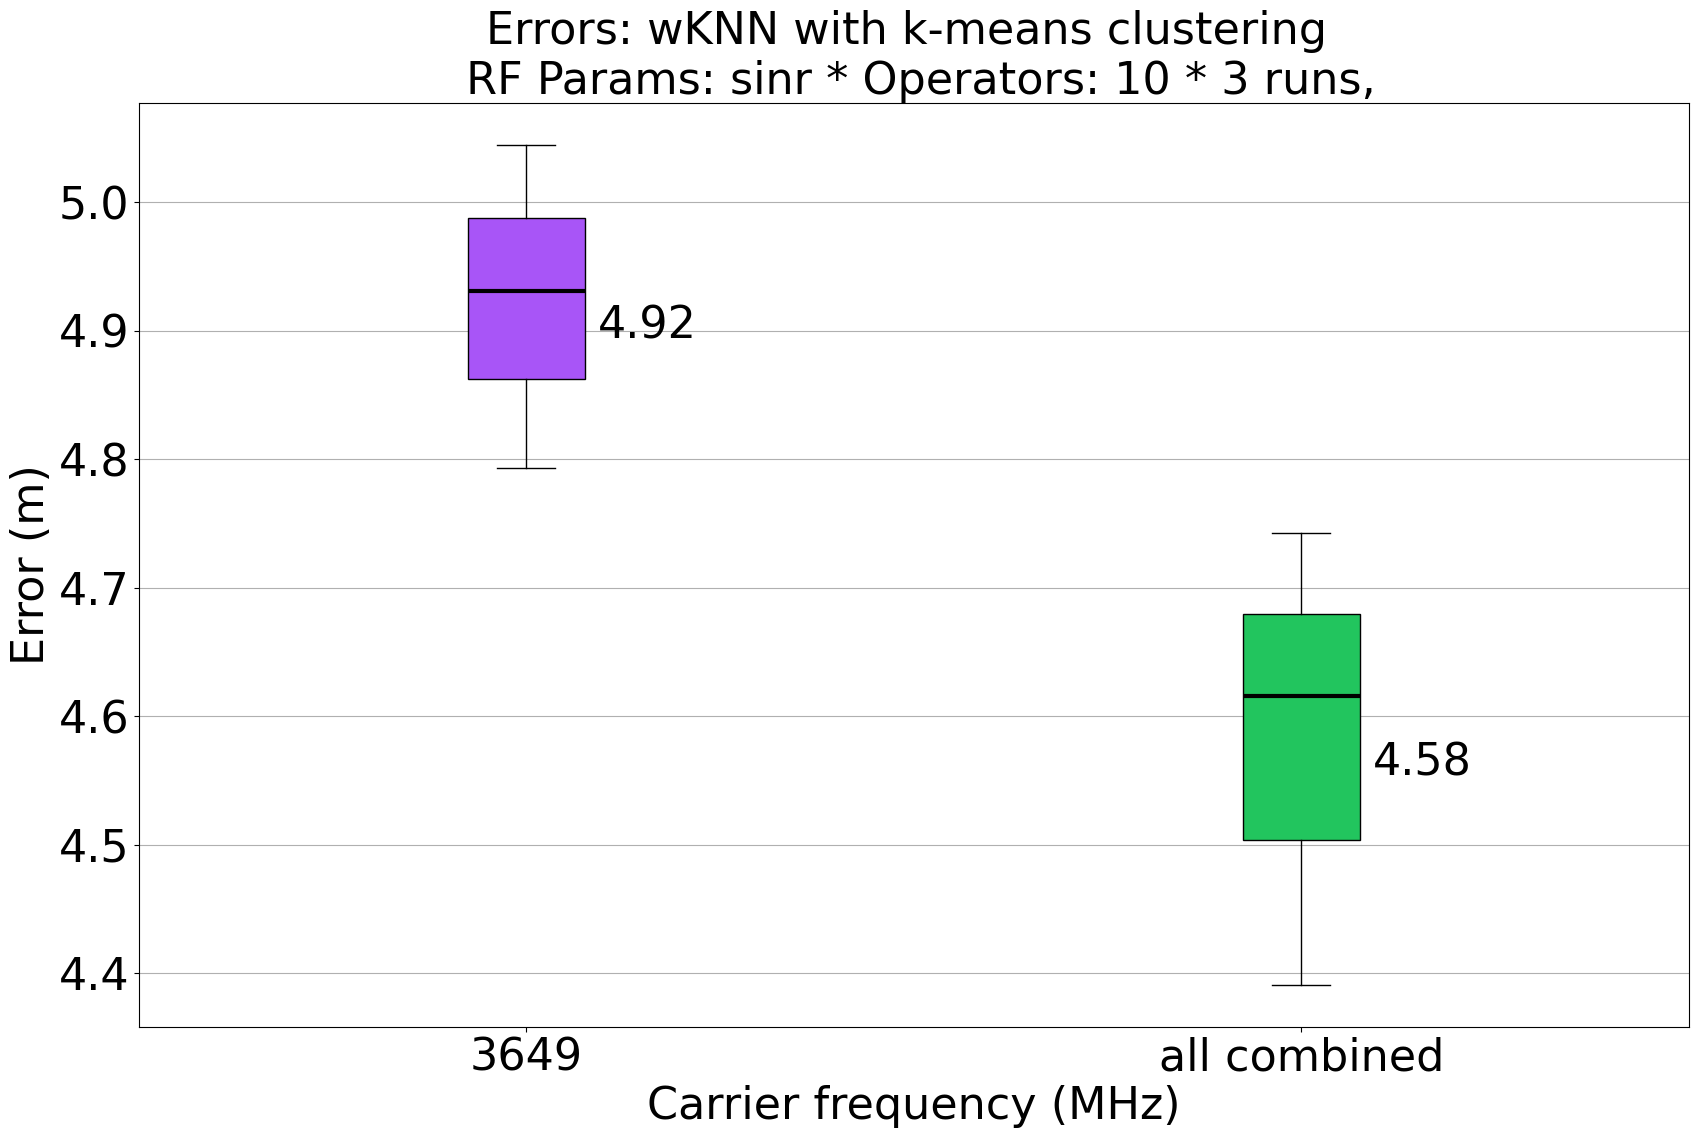

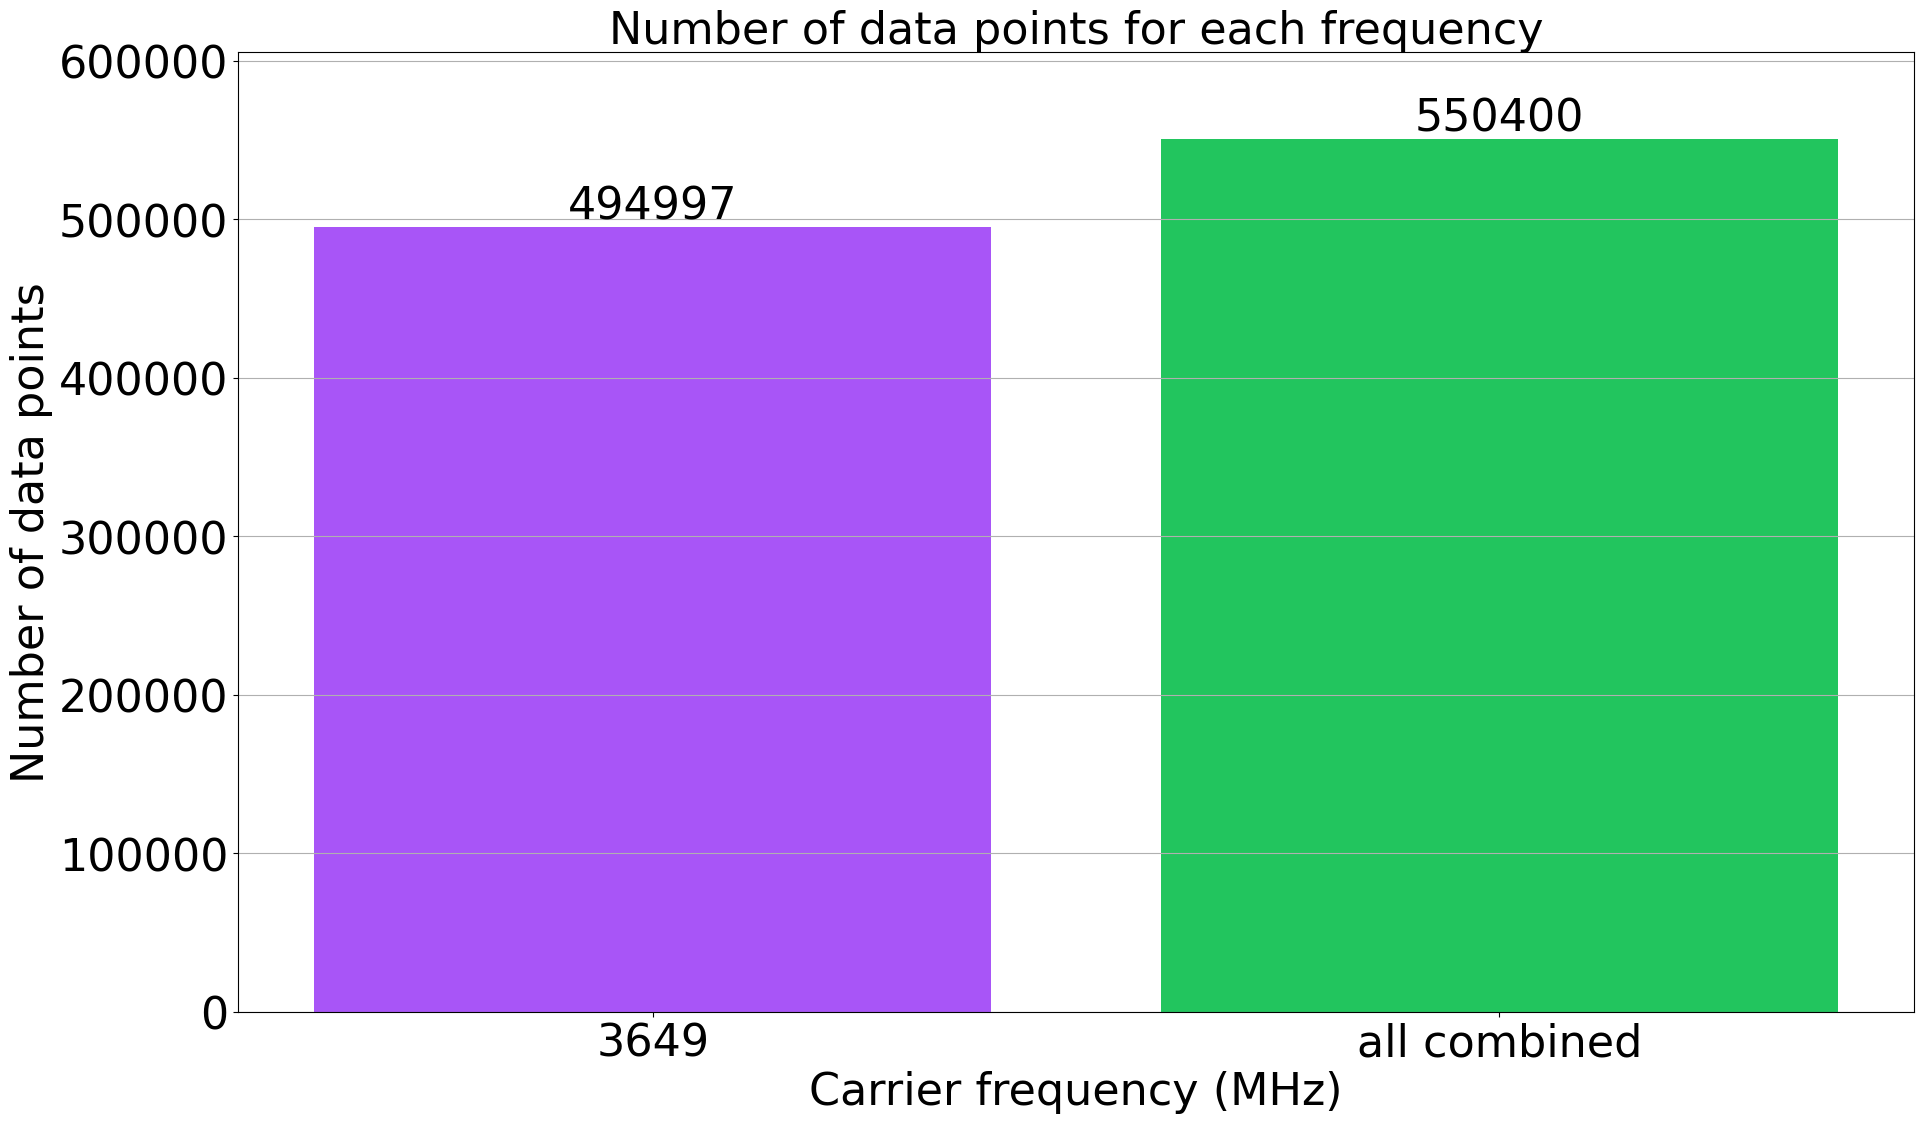

In [2]:
from scripts.plotting import make_boxplot, make_barplot
from scripts.utils import operators_to_str, get_config

errors_df = errors_df_org.copy()
entries_df = entries_df_org.copy()

# Plotting with capped runtime data
param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'
title_string = f"wKNN with k-means clustering \n {param_str} * {operator_str} * {config['n_runs']} runs,"


def rename_cols(df) -> dict[int, str]:
    return {col: 'all combined' if int(col) == 0 else str(col) for col in df.columns}


errors_df = errors_df.rename(columns=rename_cols(errors_df))
entries_df = entries_df.rename(columns=rename_cols(entries_df))

column_orders = [
    ['780', '2160', '3649', 'all combined'],
    ['3649', 'all combined']
]

color_map = get_config("color_map.json", "frequency")

for order in column_orders:
    errors_df = errors_df[order]
    entries_df = entries_df[order]

    make_boxplot(
        df=errors_df,
        title=f'Errors: {title_string}',
        x_label='Carrier frequency (MHz)',
        y_label='Error (m)',
        color=color_map,
        annotate=len(order) < 3
    )

    make_barplot(
        df=entries_df,
        title=f'Number of data points for each frequency',
        x_label='Carrier frequency (MHz)',
        y_label='Number of data points',
        color=color_map,
        annotate=True
    )
